In [2]:
# Susceptibility by dataset (R1.11b): the fitted three-coupling update read
# as a random-field Ising model P(s_i=+1) = sigmoid((h_i + (K s)_i) / T),
# swept over the temperature T; the fit itself lives at T = 1.
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import RES_DIR, MODELS, REGIMES, N_AGENTS, load_data, build_episodes

runs, banks, P, GCLASS = load_data()
coup = json.loads((RES_DIR / "couplings.json").read_text(encoding="utf-8"))
print("couplings for", list(coup["params"]))

couplings for ['gpt', 'gma', 'qwn', 'lma']


In [3]:
# sweep cut: test questions x the 4 in-distribution random graphs; each
# (graph x question) society contributes its 4 replica chains, started from
# the observed s(0)
def sweep_episodes(model, regime):
    ep = build_episodes(model, regime, runs, banks, P, GCLASS)
    keep = (ep["split"] == "test") & (ep["gcls"] == "seen")
    soc = np.array([f"{q}|g{g}" for q, g in zip(ep["qid"][keep], ep["gid"][keep])])
    return ep["phi"][keep], ep["J"][keep], ep["spins"][keep][:, 0], soc

phi, J_e, s0, soc = sweep_episodes("gpt-4o-mini", "objective")
print(f"gpt/objective: {len(phi)} chains, {len(set(soc))} societies x 4 replicas")

gpt/objective: 320 chains, 80 societies x 4 replicas


In [4]:
# chi = N Var_t(|n(t)|), the Variance of Absolute Net Opinion, per chain
# over the stationary sampling window; T_c = parabolic peak on log T
T_GRID = np.unique(np.round(np.concatenate(
    [np.geomspace(0.05, 20.0, 41), [1.0]]), 6))
BURN, SAMPLE = 200, 300

def variance_abs_net_opinion(net_sq_mean, net_abs_mean):
    return N_AGENTS * (net_sq_mean - net_abs_mean ** 2)

def sweep_at(h, K, T, s0, rng):
    E = len(h)
    s = s0.copy()
    s_abs, s_sq = np.zeros(E), np.zeros(E)
    for t in range(BURN + SAMPLE):
        u = (h + np.einsum("eij,ej->ei", K, s)) / T
        p = 1.0 / (1.0 + np.exp(-np.clip(u, -30.0, 30.0)))
        s = np.where(rng.random(p.shape) < p, 1.0, -1.0)
        if t >= BURN:
            n = s.mean(axis=1)                       # net opinion n(t)
            s_abs += np.abs(n)
            s_sq += n * n
    return variance_abs_net_opinion(s_sq / SAMPLE, (s_abs / SAMPLE))

def refine_peak(logT, chi):
    i = int(np.argmax(chi))
    if 0 < i < len(chi) - 1:
        y0, y1, y2 = chi[i - 1], chi[i], chi[i + 1]
        if y0 - 2 * y1 + y2 < 0:
            off = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2)
            return float(np.exp(logT[i] + off * (logT[i + 1] - logT[i])))
    return float(np.exp(logT[i]))

In [6]:
# run the sweep: per-society chi(T) (replica chains averaged), then the
# across-society mean/sd; mean-field reference T_MF = lambda_max(K) / 2
results = {}
for model, label, short in MODELS:
    for regime in REGIMES:
        b = coup["params"][short][regime]["three"]["betas"]
        w_field = np.array(coup["params"][short][regime]["three"]["field"])
        phi, J_e, s0_raw, soc = sweep_episodes(model, regime)
        h = phi @ w_field                            # fitted per-agent fields
        K = (b["beta_pos"] * np.maximum(J_e, 0) + b["beta_neg"] * np.minimum(J_e, 0)
             + b["beta_0"] * np.abs(J_e))
        rng = np.random.default_rng(0)
        s0 = np.where(s0_raw != 0, np.sign(s0_raw),
                      rng.choice([-1.0, 1.0], s0_raw.shape))
        ids = sorted(set(soc))
        onehot = (soc[None, :] == np.array(ids)[:, None]).astype(float)
        onehot /= onehot.sum(axis=1, keepdims=True)
        chi_soc = np.stack([onehot @ sweep_at(h, K, float(t), s0, rng)
                            for t in T_GRID], axis=1)
        lam = np.linalg.eigvalsh((K + K.transpose(0, 2, 1)) / 2)[:, -1]
        results[short, regime] = {
            "chi_mean": chi_soc.mean(axis=0), "chi_sd": chi_soc.std(axis=0),
            "tc": refine_peak(np.log(T_GRID), chi_soc.mean(axis=0)),
            "t_mf": float((onehot @ lam).mean() / 2)}
        print(f"{label:13s} {regime:10s}  {len(ids)} societies: "
              f"T_c = {results[short, regime]['tc']:.2f}")

GPT-4o-mini   subjective  40 societies: T_c = 2.69
GPT-4o-mini   objective   80 societies: T_c = 2.75
Gemma-3n-E4B  subjective  40 societies: T_c = 1.72
Gemma-3n-E4B  objective   80 societies: T_c = 1.67
Qwen3.5-9B    subjective  40 societies: T_c = 1.61
Qwen3.5-9B    objective   80 societies: T_c = 2.16
Llama-3-8B    subjective  40 societies: T_c = 2.65
Llama-3-8B    objective   80 societies: T_c = 2.98


In [7]:
pd.DataFrame({(label, rg): {
    "T_c (chi peak)": round(results[short, rg]["tc"], 2),
    "T_MF (mean-field)": round(results[short, rg]["t_mf"], 2),
    "chi at T=1": round(float(results[short, rg]["chi_mean"][T_GRID == 1.0][0]), 2)}
    for _, label, short in MODELS for rg in REGIMES}).T

T_c (chi peak)  T_MF (mean-field)  chi at T=1
GPT-4o-mini  subjective            2.69               4.30        0.39
             objective             2.75               4.48        0.43
Gemma-3n-E4B subjective            1.72               1.53        0.59
             objective             1.67               2.29        0.41
Qwen3.5-9B   subjective            1.61               2.57        0.67
             objective             2.16               3.00        0.30
Llama-3-8B   subjective            2.65               3.53        0.29
             objective             2.98               2.98        0.15

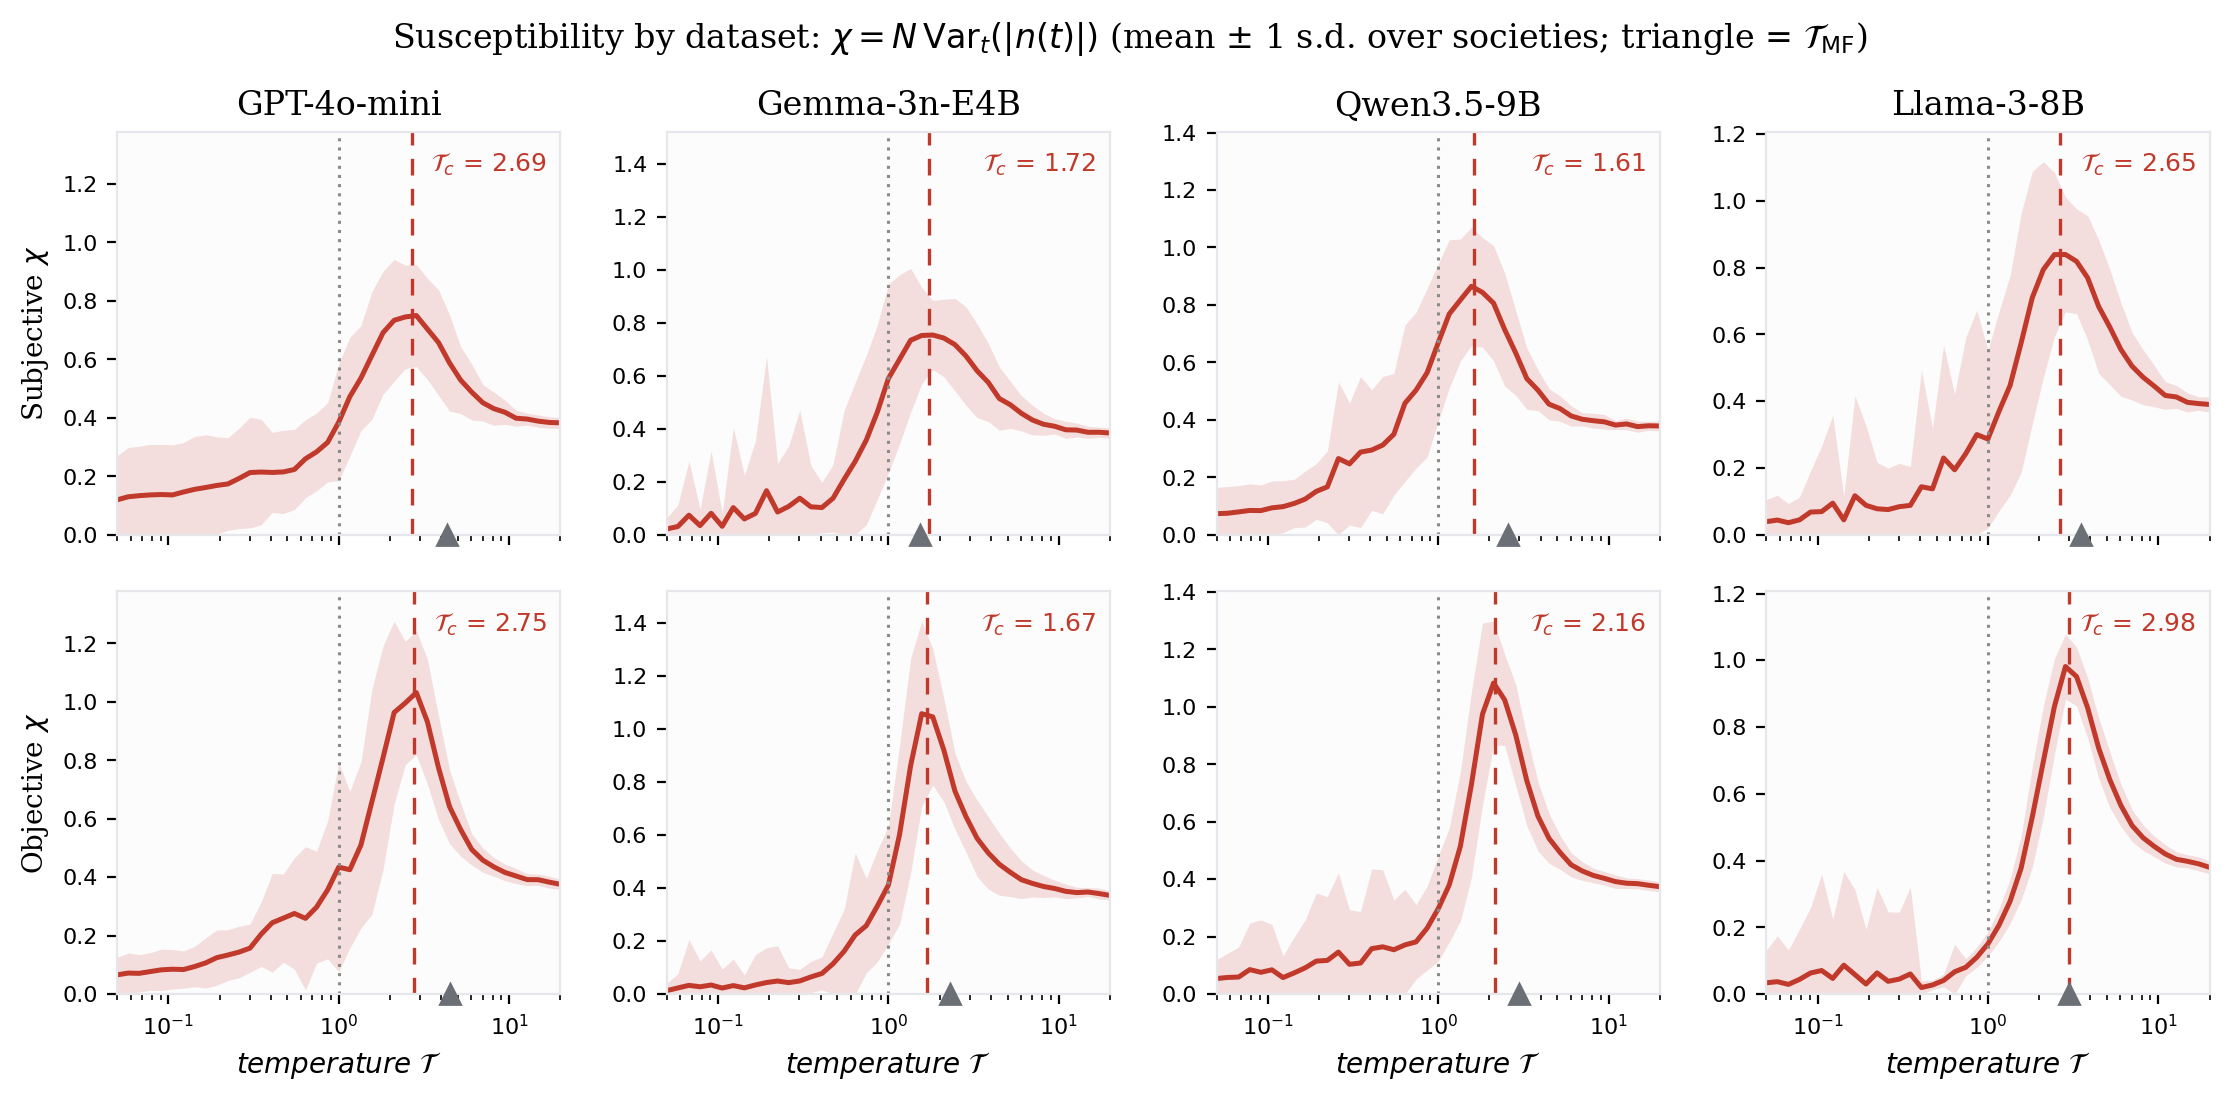

In [8]:
# 2 x 4 grid: rows = datasets, columns = models on a shared chi axis;
# every fit sits at T = 1 (dotted) below its T_c (dashed) - the ordered phase
RED = "#c0392b"
fig, axes = plt.subplots(2, 4, figsize=(13.5, 5.6), dpi=200, sharex=True,
                         gridspec_kw=dict(wspace=0.24, hspace=0.14))
for j, (model, label, short) in enumerate(MODELS):
    ymax = 1.08 * max(np.max(results[short, rg]["chi_mean"]
                             + results[short, rg]["chi_sd"]) for rg in REGIMES)
    for i, regime in enumerate(REGIMES):
        ax, res = axes[i, j], results[short, regime]
        ax.set_facecolor("#fcfcfd")
        ax.set_xscale("log")
        ax.fill_between(T_GRID, np.maximum(res["chi_mean"] - res["chi_sd"], 0),
                        res["chi_mean"] + res["chi_sd"], color=RED, alpha=0.15, lw=0)
        ax.plot(T_GRID, res["chi_mean"], color=RED, lw=1.8)
        ax.axvline(res["tc"], color=RED, ls=(0, (5, 4)), lw=1.2)
        ax.axvline(1.0, color="#8a8a86", ls=(0, (1, 2)), lw=1.1)
        ax.plot([res["t_mf"]], [0], marker="^", color="#6b6f76", ms=7,
                clip_on=False, zorder=5)
        ax.set_xlim(T_GRID[0], T_GRID[-1]), ax.set_ylim(0, ymax)
        ax.text(0.97, 0.9, f"$\\mathcal{{T}}_c$ = {res['tc']:.2f}",
                transform=ax.transAxes, ha="right", fontsize=9, color=RED)
        if i == 0:
            ax.set_title(label, fontsize=12, family="serif")
        if j == 0:
            ax.set_ylabel(f"{regime.capitalize()} $\\chi$", fontsize=10,
                          family="serif")
        if i == 1:
            ax.set_xlabel(r"temperature $\mathcal{T}$", fontsize=10,
                          style="italic")
        ax.tick_params(labelsize=8)
        for s in ax.spines.values():
            s.set_color("#e6e7eb")
fig.suptitle(r"Susceptibility by dataset: $\chi = N\,\mathrm{Var}_t(|n(t)|)$ "
             r"(mean $\pm$ 1 s.d. over societies; triangle = $\mathcal{T}_{\mathrm{MF}}$)",
             fontsize=12, family="serif")
plt.show()